<a href="https://colab.research.google.com/github/Sarumathi-G23/Convolutional-neural-network/blob/main/Fashion_dataset_using_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [14]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [16]:
x_train.shape

(60000, 28, 28)

In [17]:
y_train.shape

(60000,)

In [18]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

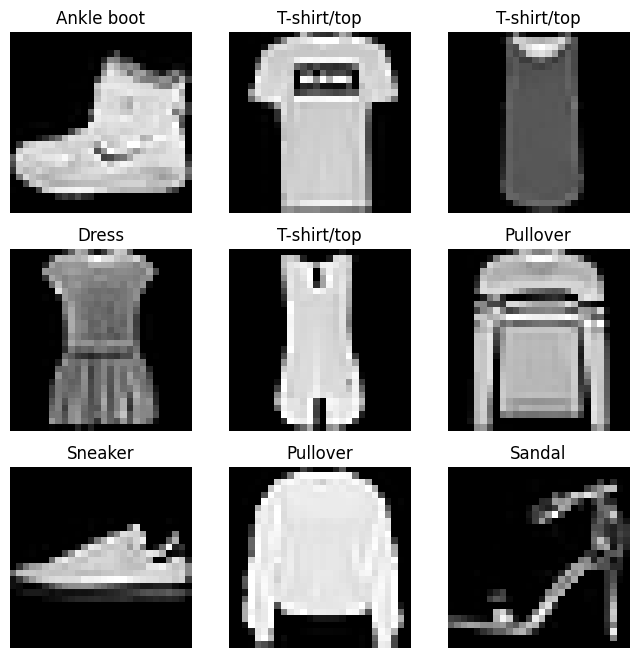

In [19]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

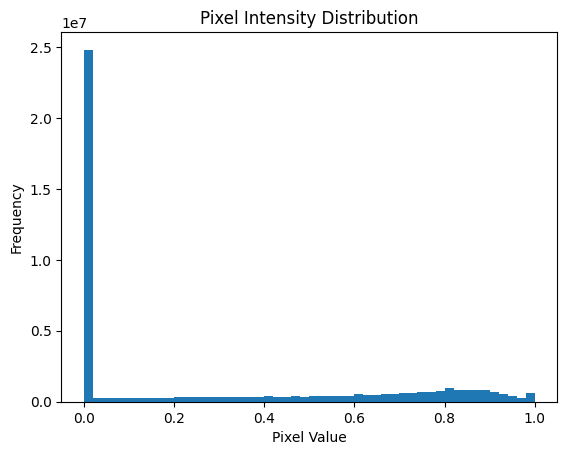

In [20]:
plt.hist(x_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [27]:
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Now, let's add the dense layers for classification.

In [28]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5)) # Adding dropout for regularization
model.add(layers.Dense(10, activation='softmax')) # 10 classes for Fashion MNIST

Next, we need to one-hot encode our labels (y_train and y_test) for categorical crossentropy loss, and then compile the model.

In [29]:
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Finally, let's train the model. This might take a few minutes.

In [30]:
history = model.fit(x_train, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.6838 - loss: 0.8874 - val_accuracy: 0.8521 - val_loss: 0.4031
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.8433 - loss: 0.4387 - val_accuracy: 0.8758 - val_loss: 0.3395
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 60ms/step - accuracy: 0.8662 - loss: 0.3754 - val_accuracy: 0.8859 - val_loss: 0.3121
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.8807 - loss: 0.3288 - val_accuracy: 0.8892 - val_loss: 0.2902
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.8886 - loss: 0.3101 - val_accuracy: 0.8982 - val_loss: 0.2735
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.8995 - loss: 0.2840 - val_accuracy: 0.8978 - val_loss: 0.2739
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 62ms/step - accuracy: 0.9047 - loss: 0.2598 - val_accuracy: 0.9078 - val_loss: 0.2558
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.9092 - loss: 0.2543 - 

In [31]:
test_loss, test_acc = model.evaluate(x_test, y_test_encoded, verbose=2)
print(f'\nTest accuracy: {test_acc}')

313/313 - 3s - 10ms/step - accuracy: 0.9057 - loss: 0.2629

Test accuracy: 0.9057000279426575


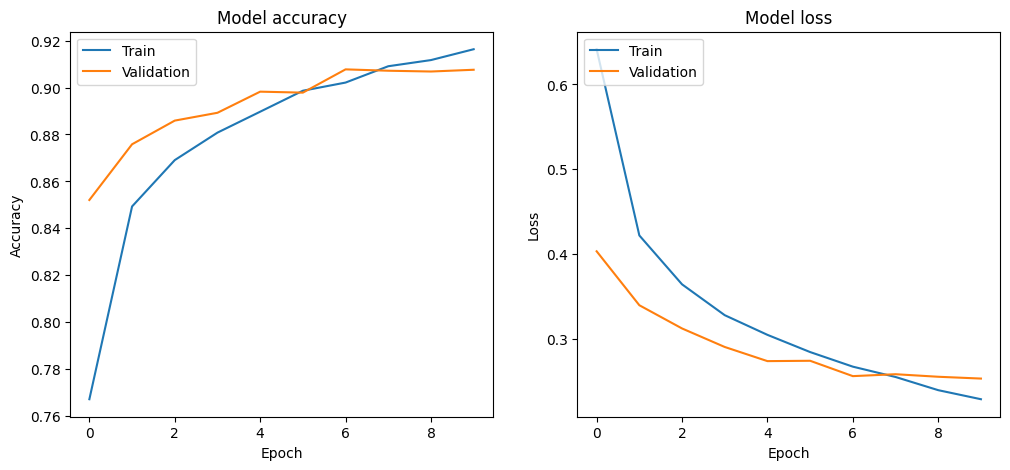

In [32]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

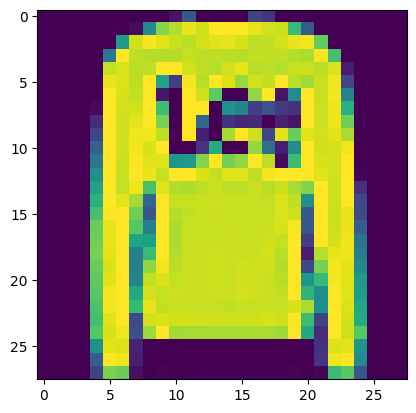

In [34]:
#visualization
import matplotlib.pyplot as plt
plt.imshow(x_test[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
y_test: T-shirt/top y_pred: Shirt


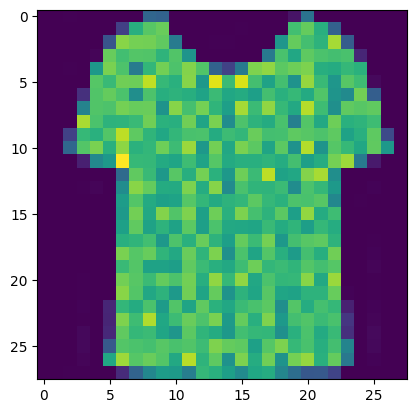

In [36]:
plt.imshow(x_test[1000])
y_pred = model.predict(x_test)
print("y_test:",class_names[np.argmax(y_test_encoded[1000])],"y_pred:",class_names[np.argmax(y_pred[1000])])